In [62]:
from utils.diffusion_model import DDPMTrainer, TrainConfig
import scanpy as sc
import anndata as ad
import numpy as np
import torch
from utils.diffusion_model import KDEMixture
import matplotlib.pyplot as plt


def adata_xy2d(adata):
    """2D (x, y) per cell: prefer obsm['spatial'][:, :2], else obs['x']/obs['y']."""
    if "spatial" in adata.obsm:
        return np.asarray(adata.obsm["spatial"], dtype=np.float64)[:, :2]
    return np.column_stack([adata.obs["x"].to_numpy(), adata.obs["y"].to_numpy()])


# Starmap evaluation

In [63]:
adata1 = sc.read_h5ad("./data/starmap/starmap_slice_1.h5ad")
adata2 = sc.read_h5ad("./data/starmap/starmap_slice_2.h5ad")
adata3 = sc.read_h5ad("./data/starmap/starmap_slice_3.h5ad")
adata4 = sc.read_h5ad("./data/starmap/starmap_slice_4.h5ad")
adata5 = sc.read_h5ad("./data/starmap/starmap_slice_5.h5ad")
adata6 = sc.read_h5ad("./data/starmap/starmap_slice_6.h5ad")
adata7 = sc.read_h5ad("./data/starmap/starmap_slice_7.h5ad")
adata8 = sc.read_h5ad("./data/starmap/starmap_slice_8.h5ad")
adata9 = sc.read_h5ad("./data/starmap/starmap_slice_9.h5ad")
slices = {1: adata1, 2: adata2, 3: adata3, 4: adata4, 5: adata5, 6: adata6, 7: adata7, 8: adata8, 9: adata9}

In [64]:
test_slices_id = [2,4,6,8]
neighbouring_slices_id = {2:[1,3], 4:[3,5], 6:[5,7], 8:[7,9]}

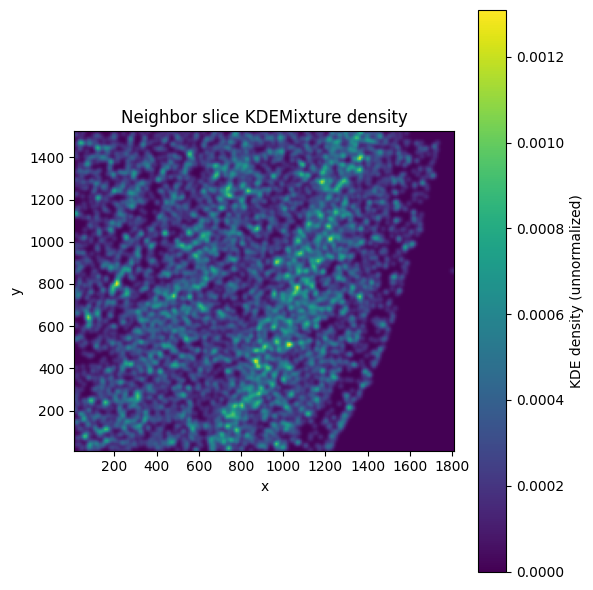

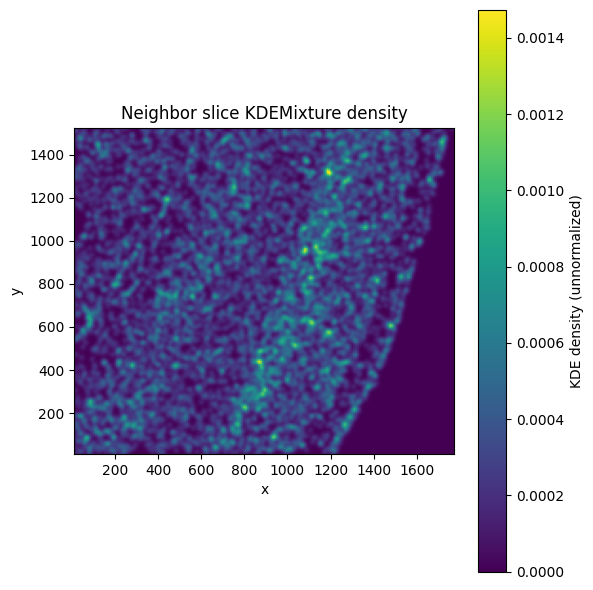

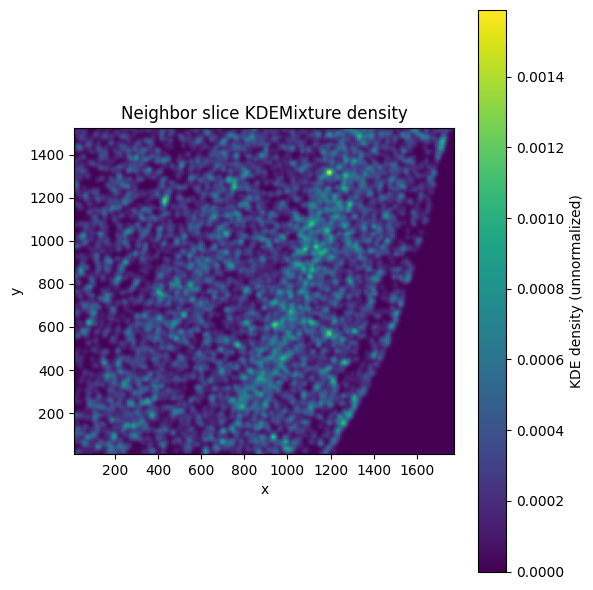

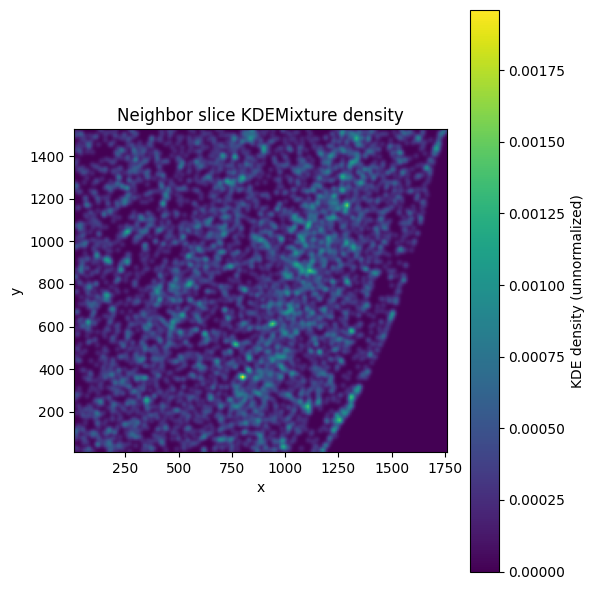

In [44]:
for slice_id in test_slices_id:
    adata = slices[slice_id]
    nbr_slice_ids = neighbouring_slices_id[slice_id]
    nbr_slices = [slices[i] for i in nbr_slice_ids]
    bottom_slice = slices[nbr_slice_ids[0]]
    top_slice = slices[nbr_slice_ids[1]]
    bottom_xy = adata_xy2d(bottom_slice)
    top_xy = adata_xy2d(top_slice)
    xy_nbr = np.vstack([bottom_xy, top_xy])
    bw = 10
    kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)  # z_factor irrelevant for 2D

    # grid to evaluate on (choose bounds from target+neighbor)
    all_xy = np.vstack([xy_nbr])
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)

    nx = ny = 200
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, nx), np.linspace(ymin, ymax, ny))
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    # call KDEMixture forward: returns (density, grad_log_density)
    with torch.no_grad():
        fvals, log_grad = kde(torch.tensor(grid), sample_frac=1.0)

    F = fvals.cpu().numpy().reshape(ny, nx)

    plt.figure(figsize=(6, 6))
    plt.imshow(F, origin="lower", extent=[xmin, xmax, ymin, ymax], aspect="equal")
    plt.colorbar(label="KDE density (unnormalized)")
    plt.title("Neighbor slice KDEMixture density")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()
            
    

In [45]:
from my_method_scvi import generate_spatial_coord_wasserstein
from utils.metrics import compute_ssim_between_densities

## Chooseing best bw

In [67]:
best_bw = {}
for test_slice_id in test_slices_id:
    
    test_slice = slices[test_slice_id]
    nbr_slice_ids = neighbouring_slices_id[test_slice_id]
    nbr_slices = [slices[i] for i in nbr_slice_ids]
    bottom_slice = slices[nbr_slice_ids[0]]
    top_slice = slices[nbr_slice_ids[1]]
    bottom_xy = adata_xy2d(bottom_slice)
    top_xy = adata_xy2d(top_slice)
    xy_nbr = np.vstack([bottom_xy, top_xy])
    best_bw[test_slice_id] = []
    possible_bw = [1,5,10,15,20,25,30]
    for bw in possible_bw:
        kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)
        torch.manual_seed(42)
        with torch.no_grad():
            kde_xy = kde.sample(int(test_slice.n_obs)).cpu().numpy()
            
        kde_adata = ad.AnnData(
            X=np.zeros((kde_xy.shape[0], test_slice.n_vars), dtype=np.float32),
            var=test_slice.var.copy(),
        )
        kde_adata.obs["x"] = kde_xy[:, 0]
        kde_adata.obs["y"] = kde_xy[:, 1]
        kde_adata.obsm["spatial"] = np.asarray(kde_xy, dtype=np.float64)
        
        kde_ssim, _, _ = compute_ssim_between_densities(
        test_slice,
        kde_adata,
        coord_keys=["x", "y"],
        grid_size=20,
        show_ssim_plots=False,
        include_gene_expression=False,
        plot_save_dir="inference/ssim",
        model_name=f"slice{test_slice_id}_kde"
        )
        best_bw[test_slice_id].append(kde_ssim)
    best_bw[test_slice_id] = possible_bw[np.argmax(best_bw[test_slice_id])]
print(best_bw)

{2: 5, 4: 25, 6: 10, 8: 5}


## Testing ssim

Begin to generate spatial coordinates......
coordinate initialization time: 0.00 seconds
Iteration 0: Loss = 32.95903015136719
Ot optimization time: 23.92 seconds


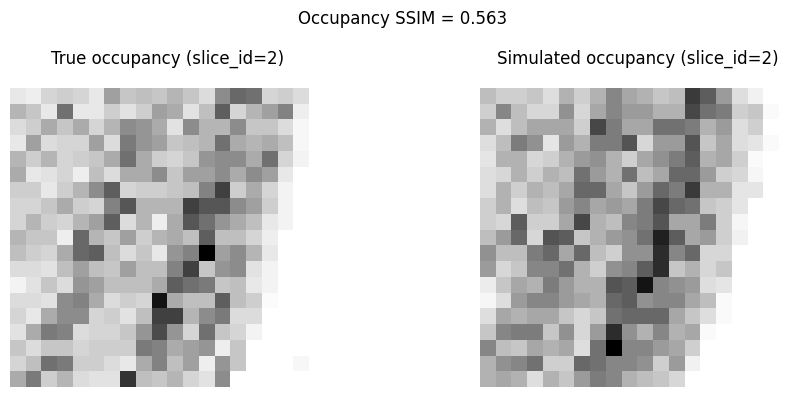

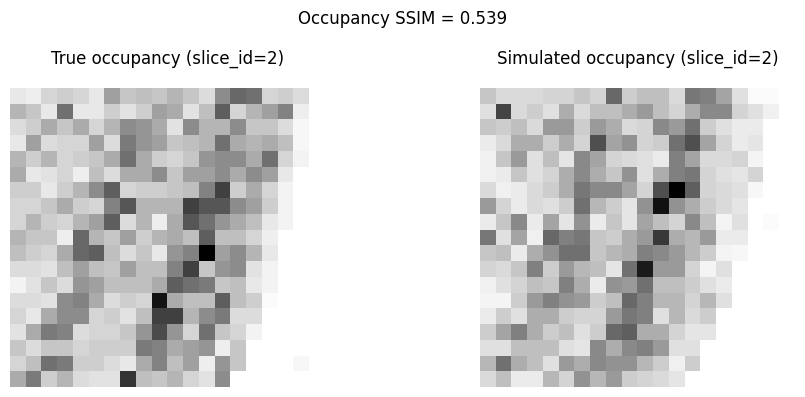

Begin to generate spatial coordinates......
coordinate initialization time: 0.00 seconds
Iteration 0: Loss = 7.678712844848633
Ot optimization time: 25.32 seconds


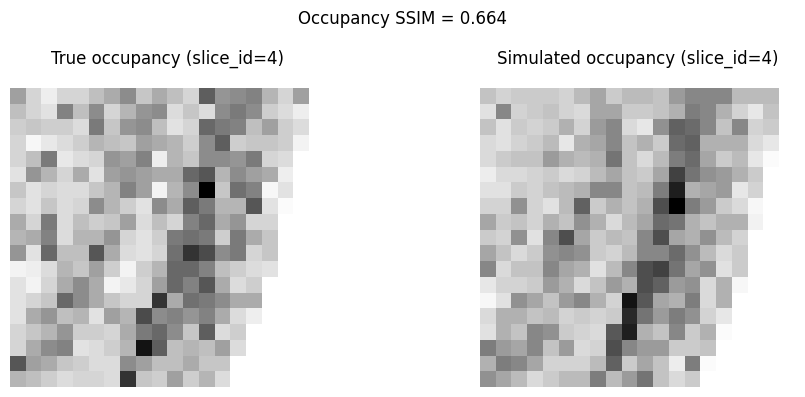

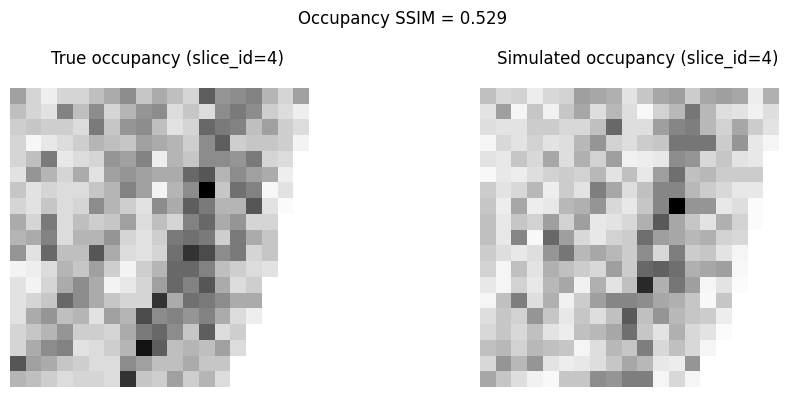

Begin to generate spatial coordinates......
coordinate initialization time: 0.00 seconds
Iteration 0: Loss = 9.341838836669922
Ot optimization time: 22.58 seconds


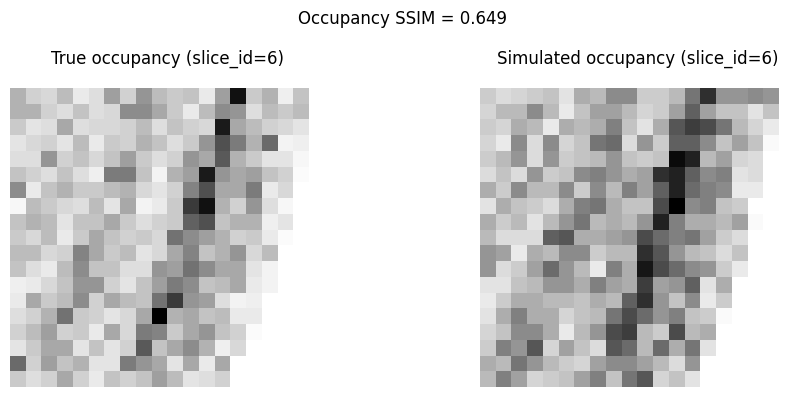

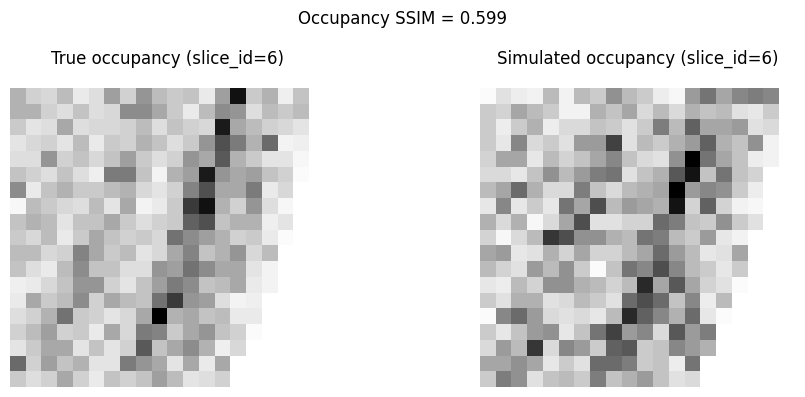

Begin to generate spatial coordinates......
coordinate initialization time: 0.00 seconds
Iteration 0: Loss = 11.681341171264648
Ot optimization time: 20.27 seconds


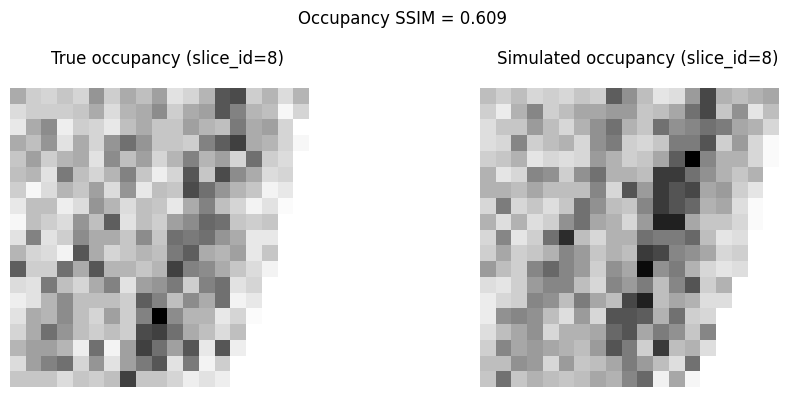

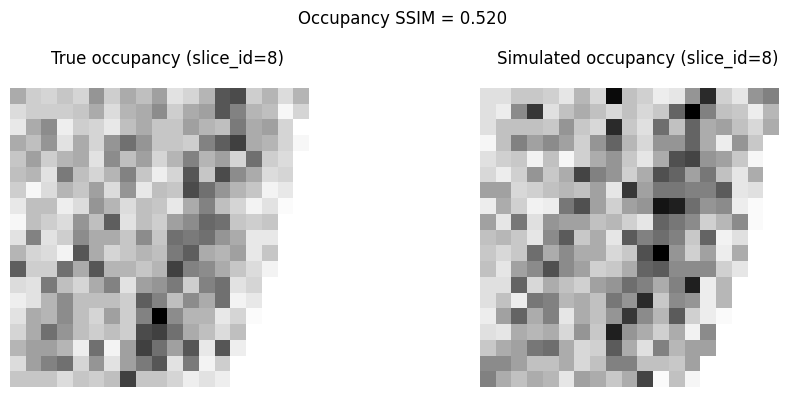

{'opt_ssim': [0.5630112575719751, 0.6643671682920422, 0.6494174698811932, 0.6085647020787605], 'kde_ssim': [0.5391767478972602, 0.5286541208627791, 0.5993978860912031, 0.5201284343067256]}


In [68]:
summarized_results = {'opt_ssim':[], 'kde_ssim':[]}
for test_slice_id in test_slices_id:
    
    test_slice = slices[test_slice_id]
    nbr_slice_ids = neighbouring_slices_id[test_slice_id]
    nbr_slices = [slices[i] for i in nbr_slice_ids]
    bottom_slice = slices[nbr_slice_ids[0]]
    top_slice = slices[nbr_slice_ids[1]]
    bottom_xy = adata_xy2d(bottom_slice)
    top_xy = adata_xy2d(top_slice)
    xy_nbr = np.vstack([bottom_xy, top_xy])
    bw = 5
    
    _, opt_xy = generate_spatial_coord_wasserstein(
    bottom_slice,
    top_slice,
    alpha=0.5,
    device="cpu",
    n_cell=test_slice.n_obs,
    n_mag=1.0,
    lr=1e5,
    nb_iter_max=100,
    seed=42,
    num_projections=80,
    verbose=True
    )
    
    kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)
    torch.manual_seed(42)
    with torch.no_grad():
        kde_xy = kde.sample(int(test_slice.n_obs)).cpu().numpy()
        
    kde_adata = ad.AnnData(
        X=np.zeros((kde_xy.shape[0], test_slice.n_vars), dtype=np.float32),
        var=test_slice.var.copy(),
    )
    kde_adata.obs["x"] = kde_xy[:, 0]
    kde_adata.obs["y"] = kde_xy[:, 1]
    kde_adata.obsm["spatial"] = np.asarray(kde_xy, dtype=np.float64)

        
    
    opt_ssim, _, _ = compute_ssim_between_densities(
        test_slice,
        opt_xy,
        coord_keys=["x", "y"],
        grid_size=20,
        show_ssim_plots=True,
        include_gene_expression=False,
        plot_save_dir="inference/ssim",
        model_name=f"slice{test_slice_id}_optimization"
    )
    
    kde_ssim, _, _ = compute_ssim_between_densities(
        test_slice,
        kde_adata,
        coord_keys=["x", "y"],
        grid_size=20,
        show_ssim_plots=True,
        include_gene_expression=False,
        plot_save_dir="inference/ssim",
        model_name=f"slice{test_slice_id}_kde"
    )
    
    summarized_results['opt_ssim'].append(opt_ssim)
    summarized_results['kde_ssim'].append(kde_ssim)
    
    
print(summarized_results)


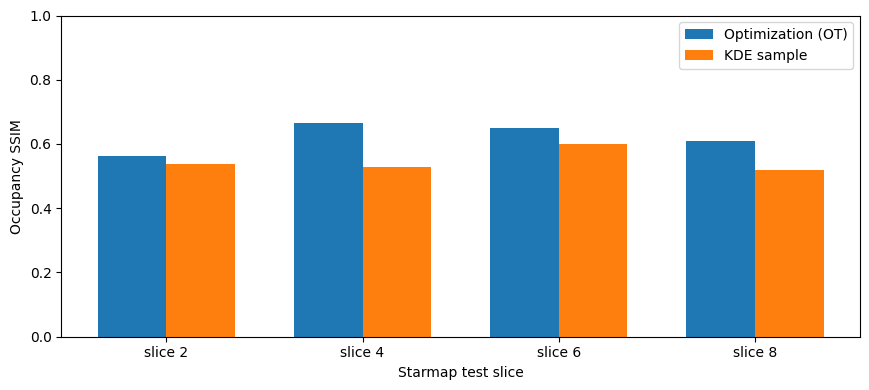

In [69]:
x = np.arange(len(test_slices_id))
width = 0.35
fig, ax = plt.subplots(figsize=(max(4.0, 2.2 * len(test_slices_id)), 4.0))
ax.bar(x - width / 2, summarized_results["opt_ssim"], width, label="Optimization (OT)")
ax.bar(x + width / 2, summarized_results["kde_ssim"], width, label="KDE sample")
ax.set_xticks(x)
ax.set_xticklabels([f"slice {sid}" for sid in test_slices_id])
ax.set_ylabel("Occupancy SSIM")
ax.set_xlabel("Starmap test slice")
ax.legend()
ax.set_ylim(0.0, 1.0)
fig.tight_layout()
plt.show()

# MERFISH evaluation

In [70]:
adata1 = sc.read_h5ad("./data/merfish/merfish_slice_1.h5ad")
adata2 = sc.read_h5ad("./data/merfish/merfish_slice_2.h5ad")
adata3 = sc.read_h5ad("./data/merfish/merfish_slice_3.h5ad")
adata4 = sc.read_h5ad("./data/merfish/merfish_slice_4.h5ad")
adata5 = sc.read_h5ad("./data/merfish/merfish_slice_5.h5ad")

slices = {1: adata1, 2: adata2, 3: adata3, 4: adata4, 5: adata5}

In [71]:
test_slices_id = [2,4]
neighbouring_slices_id = {2:[1,3], 4:[3,5]}

## Choosing best bandwidth

In [72]:
best_bw = {}
for test_slice_id in test_slices_id:
    
    test_slice = slices[test_slice_id]
    nbr_slice_ids = neighbouring_slices_id[test_slice_id]
    nbr_slices = [slices[i] for i in nbr_slice_ids]
    bottom_slice = slices[nbr_slice_ids[0]]
    top_slice = slices[nbr_slice_ids[1]]
    bottom_xy = adata_xy2d(bottom_slice)
    top_xy = adata_xy2d(top_slice)
    xy_nbr = np.vstack([bottom_xy, top_xy])
    best_bw[test_slice_id] = []
    possible_bw = [1,5,10,15,20,25,30]
    for bw in possible_bw:
        kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)
        torch.manual_seed(42)
        with torch.no_grad():
            kde_xy = kde.sample(int(test_slice.n_obs)).cpu().numpy()
            
        kde_adata = ad.AnnData(
            X=np.zeros((kde_xy.shape[0], test_slice.n_vars), dtype=np.float32),
            var=test_slice.var.copy(),
        )
        kde_adata.obs["x"] = kde_xy[:, 0]
        kde_adata.obs["y"] = kde_xy[:, 1]
        kde_adata.obsm["spatial"] = np.asarray(kde_xy, dtype=np.float64)
        
        kde_ssim, _, _ = compute_ssim_between_densities(
        test_slice,
        kde_adata,
        coord_keys=["x", "y"],
        grid_size=20,
        show_ssim_plots=False,
        include_gene_expression=False,
        plot_save_dir="inference/ssim",
        model_name=f"slice{test_slice_id}_kde"
        )
        best_bw[test_slice_id].append(kde_ssim)
    best_bw[test_slice_id] = possible_bw[np.argmax(best_bw[test_slice_id])]
print(best_bw)

{2: 20, 4: 15}


## Testing ssim

Begin to generate spatial coordinates......
coordinate initialization time: 0.01 seconds
Iteration 0: Loss = 6.677999496459961
Ot optimization time: 38.99 seconds


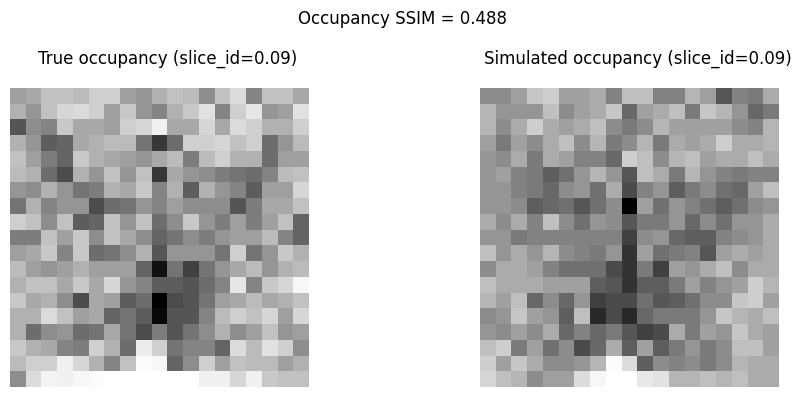

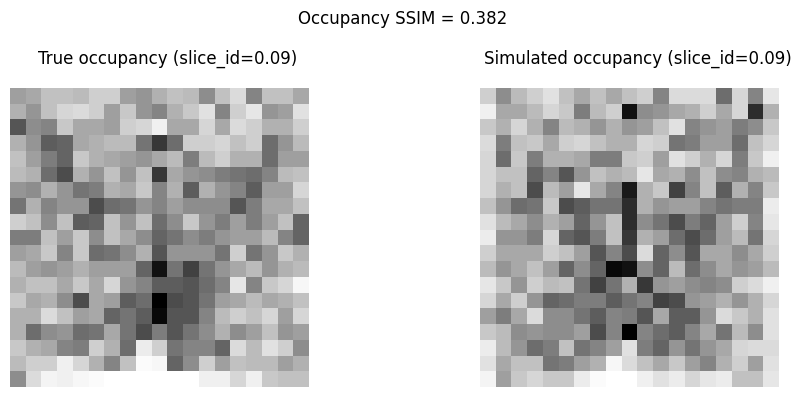

Begin to generate spatial coordinates......
coordinate initialization time: 0.00 seconds
Iteration 0: Loss = 6.681329727172852
Ot optimization time: 35.25 seconds


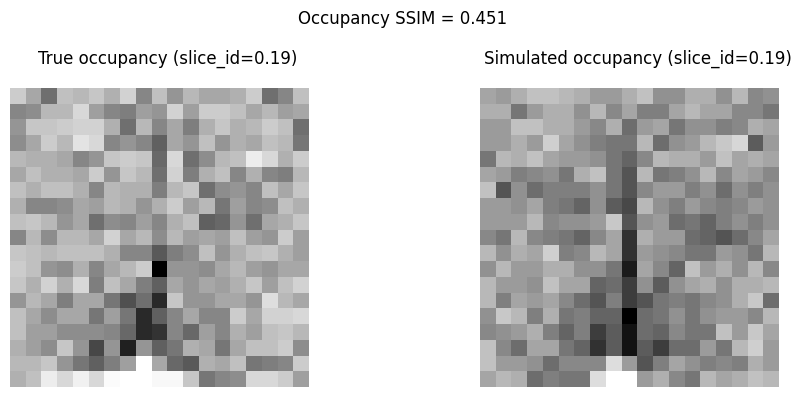

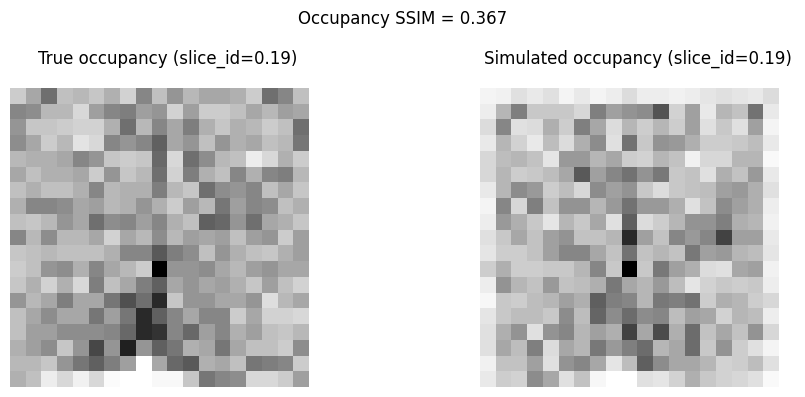

{'opt_ssim': [0.4882269517699221, 0.4508407631437341], 'kde_ssim': [0.3818012402638797, 0.3670326255118466]}


In [73]:
summarized_results = {'opt_ssim':[], 'kde_ssim':[]}
for test_slice_id in test_slices_id:
    
    test_slice = slices[test_slice_id]
    nbr_slice_ids = neighbouring_slices_id[test_slice_id]
    nbr_slices = [slices[i] for i in nbr_slice_ids]
    bottom_slice = slices[nbr_slice_ids[0]]
    top_slice = slices[nbr_slice_ids[1]]
    bottom_xy = adata_xy2d(bottom_slice)
    top_xy = adata_xy2d(top_slice)
    xy_nbr = np.vstack([bottom_xy, top_xy])
    bw = 15
    
    _, opt_xy = generate_spatial_coord_wasserstein(
    bottom_slice,
    top_slice,
    alpha=0.5,
    device="cpu",
    n_cell=test_slice.n_obs,
    n_mag=1.0,
    lr=1e5,
    nb_iter_max=100,
    seed=42,
    num_projections=80,
    verbose=True
    )
    
    kde = KDEMixture(xy_nbr, bandwidth=float(bw), z_factor=1.0)
    torch.manual_seed(42)
    with torch.no_grad():
        kde_xy = kde.sample(int(test_slice.n_obs)).cpu().numpy()
        
    kde_adata = ad.AnnData(
        X=np.zeros((kde_xy.shape[0], test_slice.n_vars), dtype=np.float32),
        var=test_slice.var.copy(),
    )
    kde_adata.obs["x"] = kde_xy[:, 0]
    kde_adata.obs["y"] = kde_xy[:, 1]
    kde_adata.obsm["spatial"] = np.asarray(kde_xy, dtype=np.float64)

        
    
    opt_ssim, _, _ = compute_ssim_between_densities(
        test_slice,
        opt_xy,
        grid_size=20,
        show_ssim_plots=True,
        include_gene_expression=False,
        plot_save_dir="inference/ssim",
        model_name=f"slice{test_slice_id}_optimization"
    )
    
    kde_ssim, _, _ = compute_ssim_between_densities(
        test_slice,
        kde_adata,
        grid_size=20,
        show_ssim_plots=True,
        include_gene_expression=False,
        plot_save_dir="inference/ssim",
        model_name=f"slice{test_slice_id}_kde"
    )
    
    summarized_results['opt_ssim'].append(opt_ssim)
    summarized_results['kde_ssim'].append(kde_ssim)
    
    
print(summarized_results)


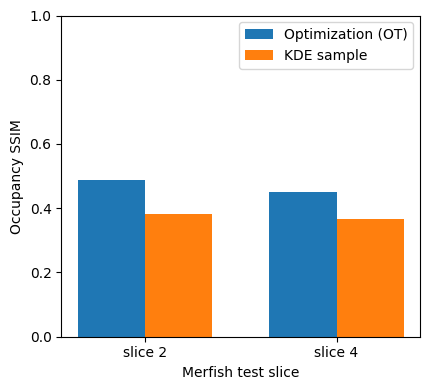

In [75]:
x = np.arange(len(test_slices_id))
width = 0.35
fig, ax = plt.subplots(figsize=(max(4.0, 2.2 * len(test_slices_id)), 4.0))
ax.bar(x - width / 2, summarized_results["opt_ssim"], width, label="Optimization (OT)")
ax.bar(x + width / 2, summarized_results["kde_ssim"], width, label="KDE sample")
ax.set_xticks(x)
ax.set_xticklabels([f"slice {sid}" for sid in test_slices_id])
ax.set_ylabel("Occupancy SSIM")
ax.set_xlabel("Merfish test slice")
ax.legend()
ax.set_ylim(0.0, 1.0)
fig.tight_layout()
plt.show()